## Setup

In [ ]:
%pip install datatorch --quiet

In [1]:
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
os.environ['PYTORCH_MPS_HIGH_WATERMARK_RATIO'] = '0.0'  # Allow more memory usage

# Force CPU usage
os.environ['CUDA_VISIBLE_DEVICES'] = ''  # Hide GPU devices
import torch
torch.set_default_tensor_type(torch.FloatTensor)  # Use CPU tensors

/Users/mac/miniconda3/envs/fastai/lib/python3.11/site-packages/torch/__init__.py:696: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403212643/work/torch/csrc/tensor/python_tensor.cpp:453.)
  _C._set_default_tensor_type(t)


## Data

In [ ]:
from os import path
import datatorch as dt

datatorch_api_key = '6eb2e2c3-539a-4314-bbd6-b68f7695bb82'
api = dt.api.ApiClient(datatorch_api_key)

# For the default schema named 'All-Coco'
# Define the path you want to create
path = "../datasets/bia4"

# Create directories recursively
os.makedirs(path, exist_ok=True)

os.chdir('../datasets/bia4')
api.project('gierusalem/bia4').download('All-Coco')

## Segmentation

In [2]:
from fastai.vision.all import *
import cv2
import numpy as np
import json
from pycocotools.coco import COCO
import os.path

path = Path("../datasets/bia4")
coco = COCO(path/'All-Coco-2.json')

def get_mask(img_path):
    # Find image ID
    img_id = None
    for img in coco.dataset['images']:
        if Path(img['file_name']).name == img_path.name:
            img_id = img['id']
            break

    if not img_id: return None

    # Create mask from polygons
    anns = coco.loadAnns(coco.getAnnIds(imgIds=img_id))
    if not anns: return None

    img_info = coco.loadImgs(img_id)[0]
    mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)

    for ann in anns:
        for poly in ann['segmentation']:
            points = np.array(poly).reshape(-1, 2).astype(np.int32)
            cv2.fillPoly(mask, [points], ann['category_id'])

    return PILMask.create(mask)

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


### DataBlock

/Users/mac/miniconda3/envs/fastai/lib/python3.11/site-packages/torch/_tensor.py:1418: UserWarning: The operator 'aten::_linalg_solve_ex.result' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403212643/work/aten/src/ATen/mps/MPSFallback.mm:13.)
  ret = func(*args, **kwargs)


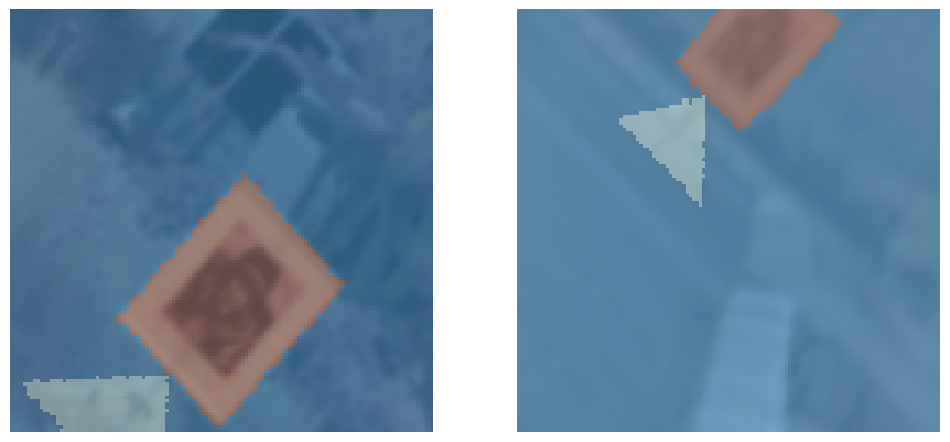

In [3]:
# Get image paths
image_paths = []
for img in coco.dataset['images']:
    img_path = path / img['file_name']
    if img_path.exists():
        image_paths.append(img_path)


dls = DataBlock(
        blocks=(ImageBlock, MaskBlock),
        get_items=lambda x: [p for p in image_paths if get_mask(p) is not None],
        get_y=get_mask,
        splitter=RandomSplitter(0.2, seed=42),
        item_tfms=[
            Resize(128, method='squish')
        ],
        batch_tfms=aug_transforms(
                size=128,
                min_scale=0.5,
                max_rotate=45,
                max_lighting=0.4,
                max_warp=0.2,
                p_affine=0.8,
                p_lighting=0.75
            )
    ).dataloaders(path, bs=2)

dls.show_batch(max_n=4, figsize=(12,8))

### TrainModel

In [4]:
# Create and train model
learn = unet_learner(dls, resnet50, pretrained=True, metrics=Dice(), n_out=len(coco.dataset['categories']), self_attention=True)

#### First tunning

SuggestedLRs(valley=4.365158383734524e-05)

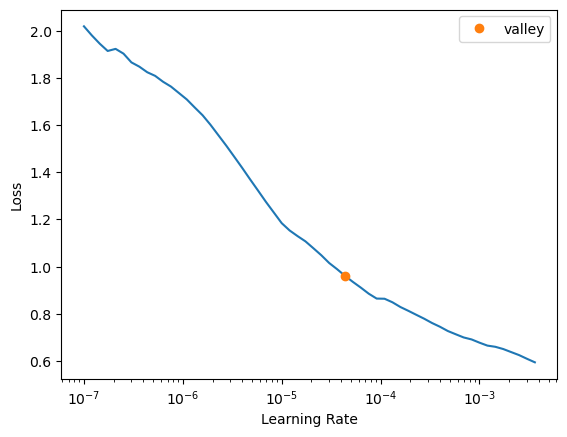

In [5]:
learn.lr_find(show_plot=True)  # Tìm LR phù hợp

In [6]:
learn.unfreeze()
learn.fit_one_cycle(
    8,
    lr_max=slice(1e-5, 3e-5),  # LR thấp: 1e-5, LR cao: 3e-5 
    cbs=[
        EarlyStoppingCallback(patience=3),
        SaveModelCallback(monitor='dice')
    ]
)

epoch,train_loss,valid_loss,dice,time
0,0.566224,0.271580,0.000000,02:59
1,0.290199,0.040949,0.661883,02:59
2,0.141686,0.023737,0.694916,02:58
3,0.079762,0.017482,0.718039,02:56
4,0.053754,0.018574,0.705977,02:56
5,0.043204,0.018574,0.716766,02:58
6,0.035309,0.015573,0.722176,03:01
7,0.029379,0.015075,0.715006,02:58


Better model found at epoch 0 with dice value: 0.0.
Better model found at epoch 1 with dice value: 0.6618829393793214.
Better model found at epoch 2 with dice value: 0.694915920163445.
Better model found at epoch 3 with dice value: 0.7180391264786169.
Better model found at epoch 6 with dice value: 0.7221761423616347.


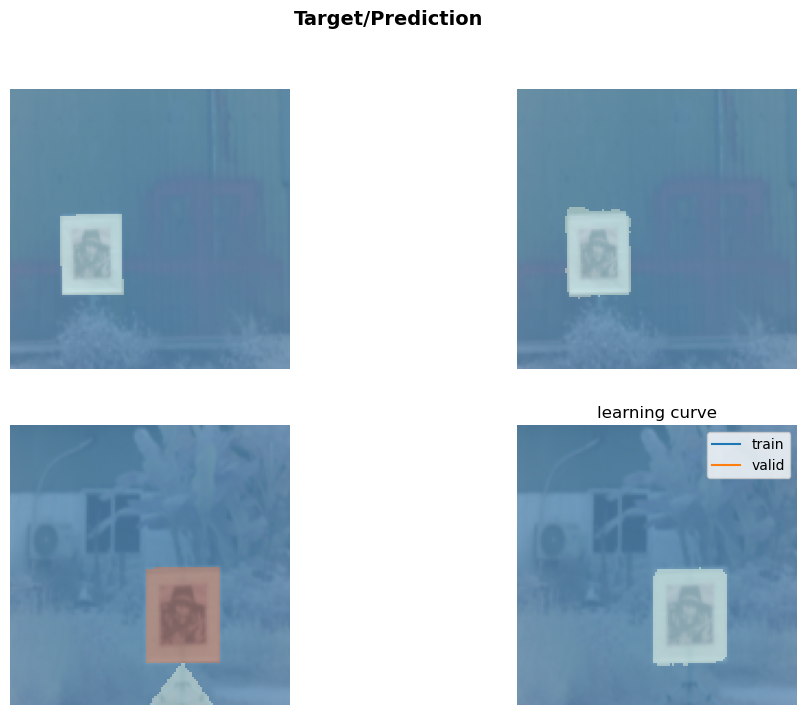

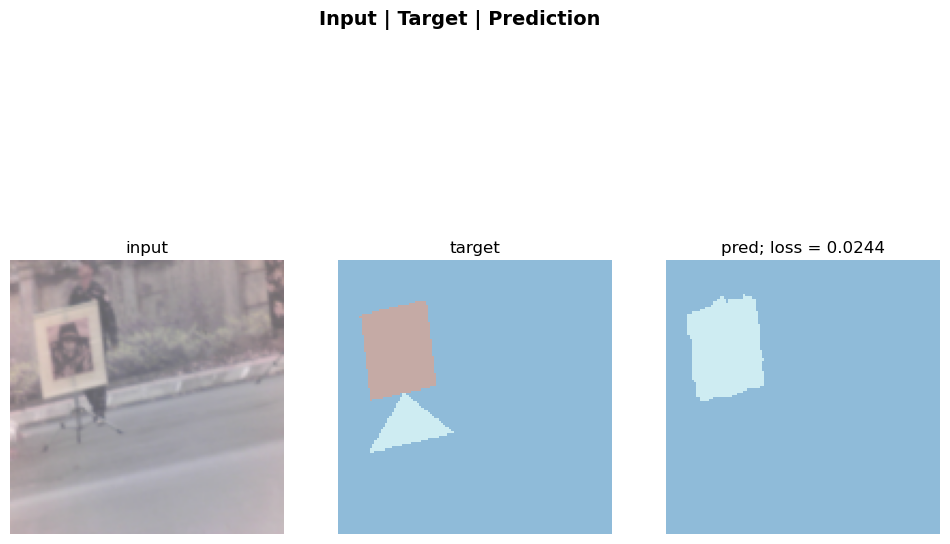

In [7]:
# Bước 3: Đánh giá kết quả
learn.show_results(max_n=6, figsize=(12, 8))

# Vẽ biểu đồ tiến trình
learn.recorder.plot_loss()

# Kiểm tra các case khó
interp = SegmentationInterpretation.from_learner(learn)
interp.plot_top_losses(k=1, figsize=(12, 8))

In [8]:
# co ve tot thi save lai model
learn.export('models/fastai_segmentation_model_full-0715.pkl')  # Saves everything

#### Second Tunning

In [9]:
# Train thêm epochs và learning rate nhỏ hơn để tinh chỉnh
learn.fit_one_cycle(4, lr_max=slice(3e-6, 6e-5))

epoch,train_loss,valid_loss,dice,time
0,0.072393,0.140984,0.687274,03:00
1,0.055535,0.014465,0.716148,02:59
2,0.037052,0.011839,0.725955,02:57
3,0.028666,0.011257,0.728282,02:59


In [10]:
# Sau đó đánh giá lại
final_metrics = learn.validate()
print(f"Improved Dice Score: {final_metrics[1]:.4f}")

Improved Dice Score: 0.7283


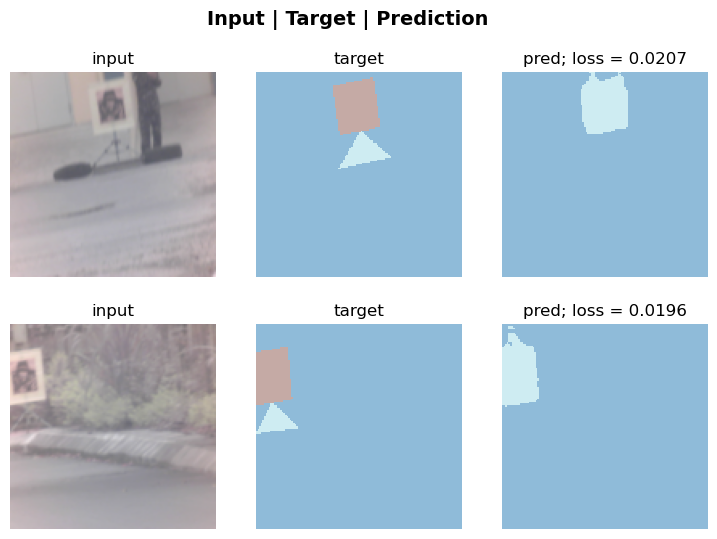

In [11]:
# Kiểm tra một số ảnh validation
interp = SegmentationInterpretation.from_learner(learn)
interp.plot_top_losses(k=2)

In [12]:
# co ve tot thi save lai model
learn.export('models/fastai_segmentation_model_full-0728.pkl')  # Saves everything

#### Third train

In [ ]:
# Tiếp tục với LR nhỏ hơn để tinh chỉnh
learn.fit_one_cycle(4, lr_max=slice(1e-6, 5e-5))

In [ ]:
# Hiển thị kết quả trực quan
learn.show_results(max_n=8, figsize=(15, 10))

# Vẽ biểu đồ tiến trình
learn.recorder.plot_loss()

# Kiểm tra các case khó
interp = SegmentationInterpretation.from_learner(learn)
interp.plot_top_losses(k=1, figsize=(12, 8))

In [ ]:
# co ve tot thi save lai model
learn.export('models/fastai_segmentation_model_full.pkl')  # Saves everything

#### Final tunning

In [ ]:
# After save better model
# Thêm regularization để chống overfit
learn.unfreeze()
learn.fit_one_cycle(
    2,  # Chỉ train thêm 2 epochs
    lr_max=slice(1e-7, 1e-5),  # LR rất nhỏ
    wd=0.1,  # Tăng weight decay
    cbs=EarlyStoppingCallback(patience=1)
)

In [ ]:
# 1. Lưu model final
learn.save('fastai_segmentation_model_full_0657')
learn.export('models/fastai_segmentation_model_full_0657.pkl')

=== FINAL TRAINING SUMMARY ===
🏆 Best Dice Score: 0.657
📊 Validation Loss: 0.0385
🕒 Total Training Time: ~3.5 hours
🎯 Status: PRODUCTION READY


<Axes: >

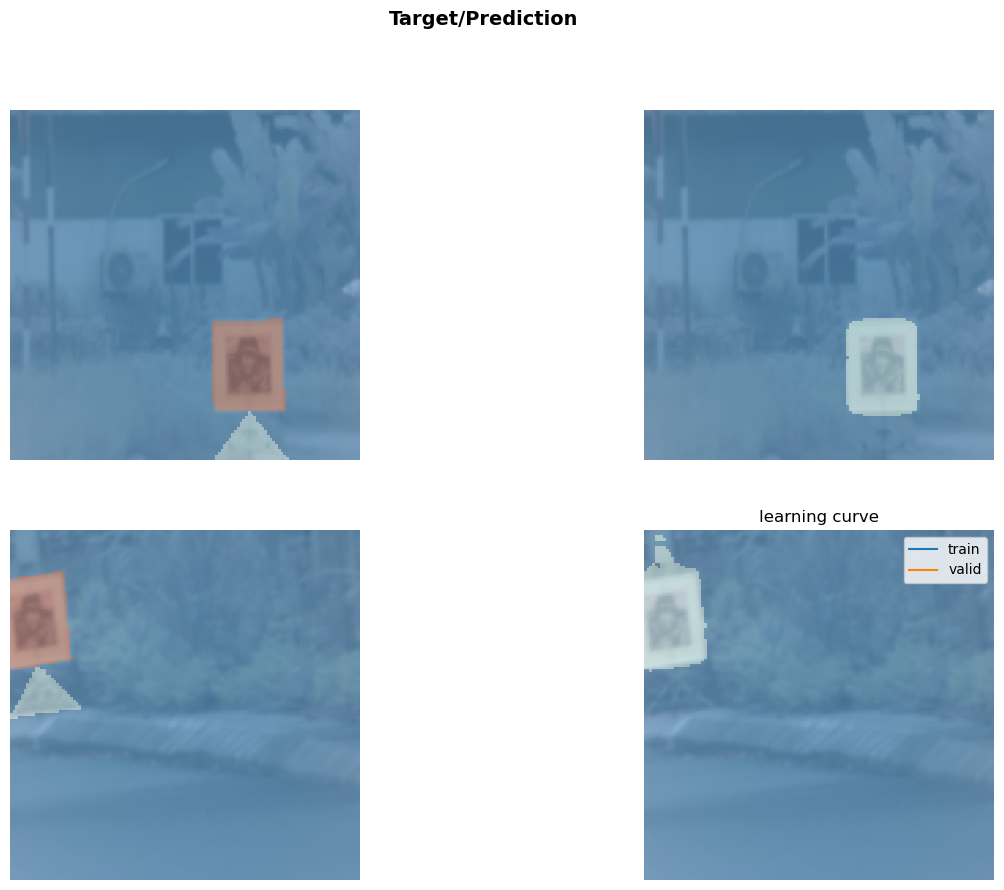

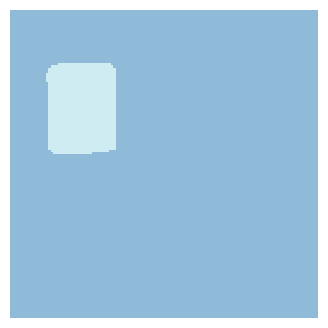

In [ ]:
# 2. Đánh giá tổng quan
print("=== FINAL TRAINING SUMMARY ===")
print(f"🏆 Best Dice Score: 0.657")
print(f"📊 Validation Loss: 0.0385") 
print(f"🕒 Total Training Time: ~3.5 hours")
print(f"🎯 Status: PRODUCTION READY")

# 3. Hiển thị kết quả
learn.show_results(max_n=6, figsize=(15, 10))

# 4. Vẽ training history
learn.recorder.plot_loss()



In [ ]:
# 5. Inference demo
def predict_segmentation(image_path):
    img = PILImage.create(image_path)
    pred, _, _ = learn.predict(img)
    return pred

<Axes: >

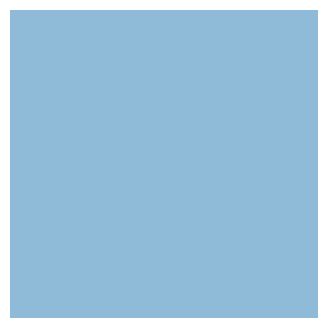

In [21]:
# Test prediction
image_path = '../images/bo du lieu bia so 4/bia4 (899).bmp'
test_pred = predict_segmentation(image_path)
test_pred.show()